#IMPORT LIBRARY DASAR

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset dan modul scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Agar plot tampil rapi
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

In [55]:
from google.colab import drive
import pandas as pd

drive.mount('/content/gdrive')

# Tentukan path file (sesuaikan dengan lokasi folder Anda di Drive)
path = "/content/drive/MyDrive/Mecine Learning/Praktikum12/data"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#MEMBERSIHKAN DATA

In [57]:
cols_to_drop = ['id', 'Unnamed: 32']
df = df.drop([c for c in cols_to_drop if c in df.columns], axis=1)

In [59]:
# Membuat DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

In [60]:
# Menampilkan informasi dataset
print("Shape Data:", df.shape) # (569, 31)
print("\n5 Baris Pertama Data:")
display(df.head())

Shape Data: (569, 31)

5 Baris Pertama Data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#PEMISAHAN FITUR DAN LABEL

In [61]:
X = cancer.data
y = cancer.target

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")


Shape X: (569, 30)
Shape y: (569,)


#PEMBAGIAN DATA LATIH DAN UJI (TRAIN-TEST SPLIT)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (455, 30)
Shape X_test: (114, 30)


#STANDARDISASI FITUR (SCALING)

In [63]:
scaler = StandardScaler()

# Fit pada training, transform pada training & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL BASELINE: SVM TANPA PCA

In [64]:
print("\n--- 2. TRAINING SVM TANPA PCA (BASELINE) ---")
# Menggunakan parameter 'rbf' sesuai modul (Halaman 11)
svm_full = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_full.fit(X_train_scaled, y_train)

y_pred_full = svm_full.predict(X_test_scaled)
acc_full = accuracy_score(y_test, y_pred_full)
print(f"Akurasi SVM Tanpa PCA (30 Fitur): {acc_full:.4f}")


--- 2. TRAINING SVM TANPA PCA (BASELINE) ---
Akurasi SVM Tanpa PCA (30 Fitur): 0.9825


#IMPLEMENTASI PCA

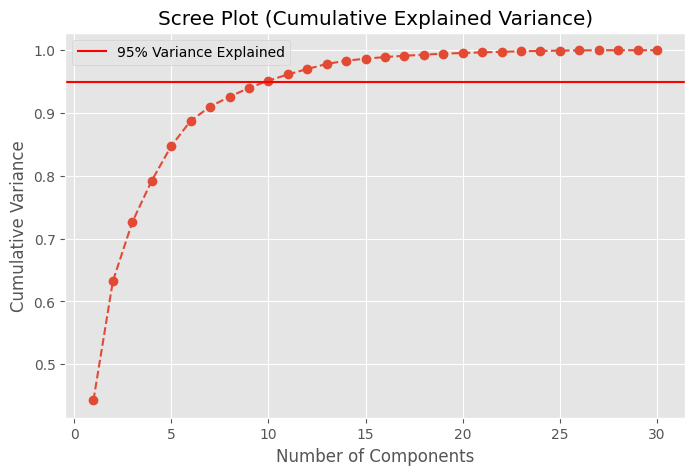

In [65]:
scaler_full_data = StandardScaler() # Create a new scaler for the full dataset
X_scaled = scaler_full_data.fit_transform(X) # Scale the entire X dataset
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Explained')
plt.title('Scree Plot (Cumulative Explained Variance)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
print("\n--- IMPLEMENTASI PCA ---")

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Shape X_train_pca: {X_train_pca.shape}") # Menjadi 2 kolom saja
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Informasi tersimpan: {sum(pca.explained_variance_ratio_) * 100:.2f}%")


--- IMPLEMENTASI PCA ---
Shape X_train_pca: (455, 2)
Explained Variance Ratio: [0.44413492 0.18944618]
Total Informasi tersimpan: 63.36%


#MEMBANGUN MODEL SVM DENGAN PCA

In [67]:
print("\n--- TRAINING SVM DENGAN PCA ---")
# Menggunakan kernel yang sama ('rbf') agar perbandingan adil
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Akurasi SVM Dengan PCA (2 Fitur): {acc_pca:.4f}")
print("\nClassification Report (Model PCA):")
print(classification_report(y_test, y_pred_pca, target_names=cancer.target_names))


--- TRAINING SVM DENGAN PCA ---
Akurasi SVM Dengan PCA (2 Fitur): 0.9474

Classification Report (Model PCA):
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



#VISUALISASI HASIL PCA

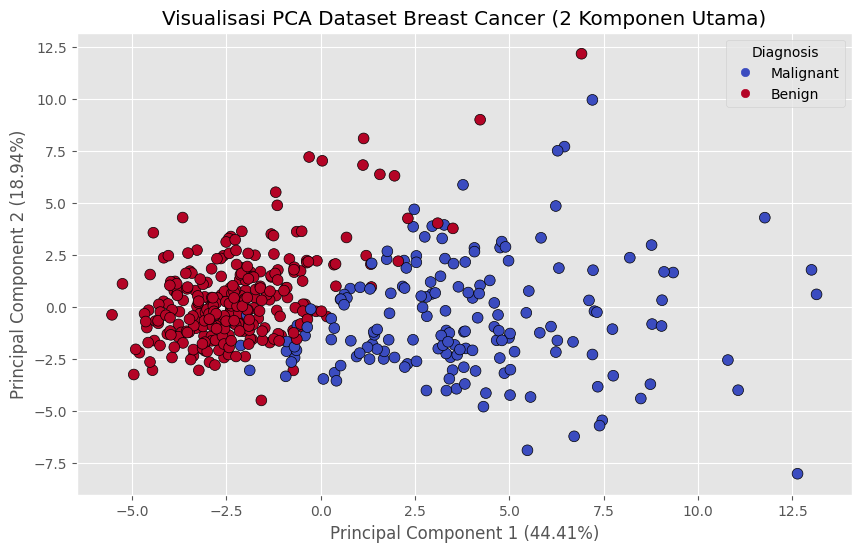

In [68]:
plt.figure(figsize=(10, 6))

# Plotting scatter plot
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolor='k',
    s=60
)

# Judul dan Label Sumbu (Penting: Menampilkan % Variance)
plt.title('Visualisasi PCA Dataset Breast Cancer (2 Komponen Utama)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')

# Membuat Legenda
# PENTING: Kita pakai variable 'target_names' yang sudah dibuat saat Load CSV
handles, _ = scatter.legend_elements()
plt.legend(handles, target_names, title="Diagnosis")

plt.grid(True)
plt.show()

In [69]:
print("\n" + "="*50)
print("KESIMPULAN AKHIR")
print("="*50)

# 1. Tabel Perbandingan (Ringkas & Jelas)
print(f"\n{'Metode':<25} | {'Akurasi':<10} | {'Jumlah Fitur':<15}")
print("-" * 55)
print(f"{'Original (Tanpa PCA)':<25} | {acc_full:.4f}     | {X_train.shape[1]}")
print(f"{'Dengan PCA (2 Komponen)':<25} | {acc_pca:.4f}     | {X_train_pca.shape[1]}")
print("-" * 55)

# 2. Detail Laporan (Penting untuk Data Medis)
print("\n--- DETAIL CLASSIFICATION REPORT ---")

print("\n1. Original (30 Fitur):")
print(classification_report(y_test, y_pred_full, target_names=target_names))

print("\n2. PCA (2 Fitur Utama):")
# PERBAIKAN: Gunakan y_test, bukan y_test_pca
print(classification_report(y_test, y_pred_pca, target_names=target_names))


KESIMPULAN AKHIR

Metode                    | Akurasi    | Jumlah Fitur   
-------------------------------------------------------
Original (Tanpa PCA)      | 0.9825     | 30
Dengan PCA (2 Komponen)   | 0.9474     | 2
-------------------------------------------------------

--- DETAIL CLASSIFICATION REPORT ---

1. Original (30 Fitur):
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


2. PCA (2 Fitur Utama):
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95     